# Análise Comparativa Multi-Modelo

Este notebook analisa os resultados dos experimentos da Fase 4, comparando diferentes modelos NLG (Gemma, Llama, Mistral, Phi) executando a mesma persona freiriana.

## Objetivos da Análise:
1. **Performance Técnica**: Latência, uso de VRAM/RAM
2. **Qualidade Pedagógica**: Manutenção de persona, scaffolding, uso de ferramentas
3. **Comparação com Baseline**: Gemma vs. outros modelos
4. **Identificação de Problemas**: Loops, quebra de regras, etc.

In [7]:
# Imports
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Any

# Configuração de visualização
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Carregar Dados dos Experimentos

In [10]:
def load_experiment_data(base_log_dir: str | None = None) -> Dict[str, pd.DataFrame]:
    """Carrega dados dos experimentos multi-modelo.

    Vasculha a estrutura de logs criada pelo runner multi-modelo, suportando
    múltiplos cenários por modelo (ex.: standard_enem, scaffolding_complex_enem).
    Retorna um dicionário onde cada chave é o nome do modelo e o DataFrame agrega
    todas as interações daquele modelo, com colunas extras para cenário e experimento.
    """
    candidate_paths = []
    if base_log_dir:
        candidate_paths.append(Path(base_log_dir))
    candidate_paths.extend([
        Path('logs/experiments'),
        Path('../logs/experiments'),
        Path('../../logs/experiments'),
        Path('../../../logs/experiments'),
        Path('../../../../logs/experiments'),
    ])

    base_path = None
    for candidate in candidate_paths:
        resolved = candidate.resolve()
        if resolved.exists():
            base_path = resolved
            break

    if base_path is None:
        raise FileNotFoundError(
            'Não foi possível localizar a pasta de logs. Verifique as rotas: '
            + ', '.join(str(path) for path in candidate_paths)
        )

    print(f'Base de logs localizada em: {base_path}')

    all_data: Dict[str, pd.DataFrame] = {}

    for experiment_dir in sorted(base_path.glob('*')):
        if not experiment_dir.is_dir():
            continue

        for model_dir in sorted(experiment_dir.glob('*')):
            if not model_dir.is_dir():
                continue

            aggregated_frames: List[pd.DataFrame] = []

            # Primeiro, procurar por arquivos diretamente no diretório do modelo
            direct_interactions = model_dir / 'interactions.jsonl'
            if direct_interactions.exists():
                df = _load_interactions(direct_interactions)
                df['scenario'] = 'default'
                df['experiment'] = experiment_dir.name
                aggregated_frames.append(df)

            # Depois, procurar por subpastas de cenários (standard_enem, etc.)
            for scenario_dir in sorted(model_dir.glob('*')):
                if scenario_dir.is_dir():
                    interactions_file = scenario_dir / 'interactions.jsonl'
                    if interactions_file.exists():
                        df = _load_interactions(interactions_file)
                        df['scenario'] = scenario_dir.name
                        df['experiment'] = experiment_dir.name
                        aggregated_frames.append(df)

            if aggregated_frames:
                model_name = model_dir.name
                all_data[model_name] = pd.concat(aggregated_frames, ignore_index=True)
                total_turns = sum(len(frame) for frame in aggregated_frames)
                print(f'✓ Carregado: {model_name} ({total_turns} interações, {len(aggregated_frames)} cenários)')

    if not all_data:
        print('⚠️ Nenhum dado encontrado. Verifique se os experimentos foram executados.')

    return all_data


def _load_interactions(interactions_file: Path) -> pd.DataFrame:
    """Lê um arquivo JSONL de interações e retorna um DataFrame."""
    interactions: List[Dict[str, Any]] = []
    with interactions_file.open('r', encoding='utf-8') as handler:
        for line in handler:
            if line.strip():
                interactions.append(json.loads(line))
    return pd.DataFrame(interactions)


# Carregar dados
data = load_experiment_data()
print(f"Total de modelos: {len(data)}")

Base de logs localizada em: /Users/giossaurus/Developer/leia_tcc/logs/experiments
✓ Carregado: Qwen_Qwen2.5-7B-Instruct (29 interações, 5 cenários)
✓ Carregado: google_gemma-2-2b-it (21 interações, 4 cenários)
✓ Carregado: mistralai_Mistral-7B-Instruct-v0.2 (29 interações, 5 cenários)
Total de modelos: 3


## 2. Performance Técnica - Tabela Comparativa

In [11]:
def compute_technical_metrics(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Calcula métricas técnicas por modelo.
    """
    metrics = []
    
    for model_name, df in data.items():
        metrics.append({
            "Modelo": model_name,
            "Latência Média (ms)": df['latency_ms'].mean(),
            "Latência Min (ms)": df['latency_ms'].min(),
            "Latência Max (ms)": df['latency_ms'].max(),
            "VRAM Máxima (MB)": df['vram_used_mb'].max() if 'vram_used_mb' in df.columns else 0,
            "VRAM Média (MB)": df['vram_used_mb'].mean() if 'vram_used_mb' in df.columns else 0,
            "RAM Máxima (MB)": df['ram_used_mb'].max() if 'ram_used_mb' in df.columns else 0,
            "Total de Turnos": len(df),
        })
    
    return pd.DataFrame(metrics).round(2)

# Gerar tabela
technical_metrics = compute_technical_metrics(data)
print("\n=== TABELA DE PERFORMANCE TÉCNICA ===")
display(technical_metrics)


=== TABELA DE PERFORMANCE TÉCNICA ===


,Modelo,Latência Média (ms),Latência Min (ms),Latência Max (ms),VRAM Máxima (MB),VRAM Média (MB),RAM Máxima (MB),Total de Turnos
0,Qwen_Qwen2.5-7B-Instruct,124996.76,13439.72,330123.36,0.0,0.0,22430.83,29
1,google_gemma-2-2b-it,21191.33,2376.18,116975.44,0.0,0.0,19288.66,21
2,mistralai_Mistral-7B-Instruct-v0.2,46174.75,10247.28,135211.72,0.0,0.0,23645.94,29


## 3. Visualização - Latência Comparativa

/var/folders/k4/x1x0j4qs0svb48fpvhhvkmbh0000gn/T/ipykernel_98385/3398019110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=technical_metrics, x='Modelo', y='Latência Média (ms)', palette='viridis')


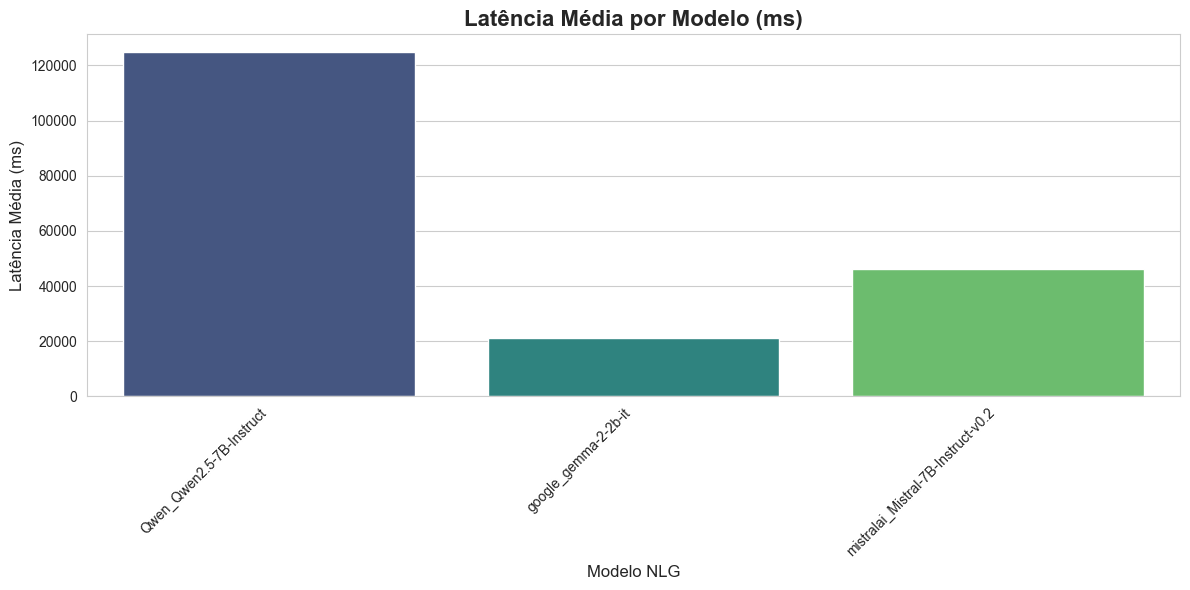

/var/folders/k4/x1x0j4qs0svb48fpvhhvkmbh0000gn/T/ipykernel_98385/3398019110.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=latency_data, x='model_name', y='latency_ms', palette='Set2')


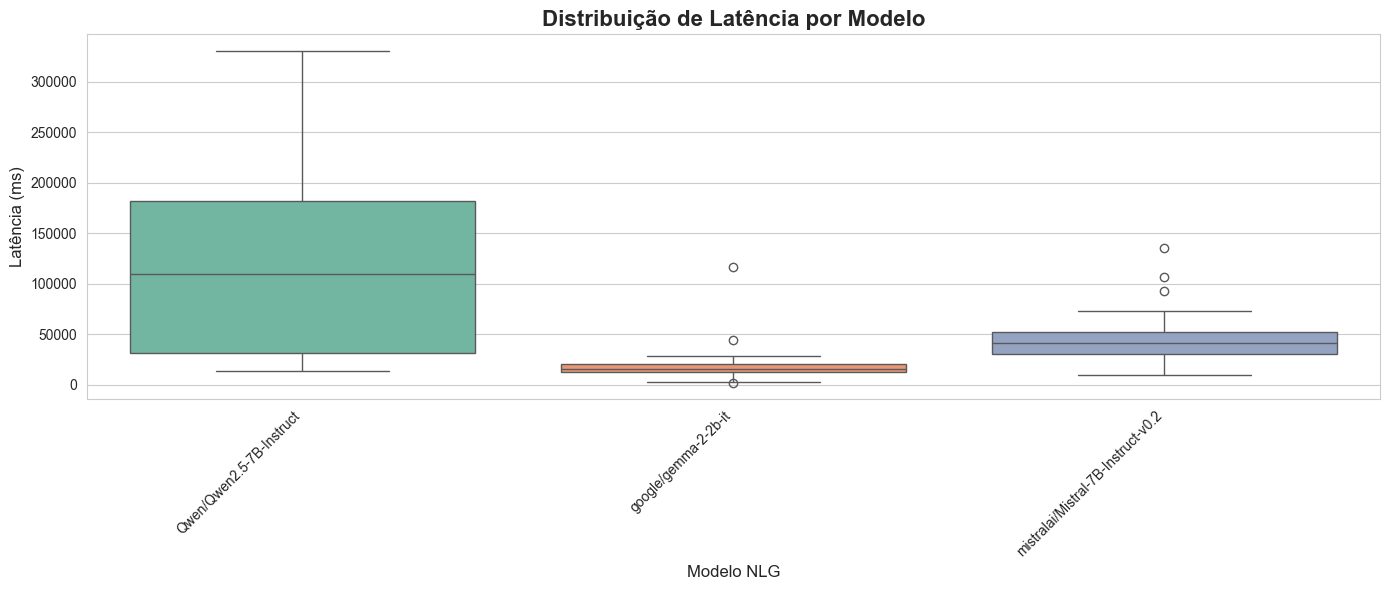

In [12]:
# Gráfico de barras - Latência média
plt.figure(figsize=(12, 6))
sns.barplot(data=technical_metrics, x='Modelo', y='Latência Média (ms)', palette='viridis')
plt.title('Latência Média por Modelo (ms)', fontsize=16, fontweight='bold')
plt.xlabel('Modelo NLG', fontsize=12)
plt.ylabel('Latência Média (ms)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Box plot - Distribuição de latências
plt.figure(figsize=(14, 6))
latency_data = pd.concat([df[['model_name', 'latency_ms']] for df in data.values()])
sns.boxplot(data=latency_data, x='model_name', y='latency_ms', palette='Set2')
plt.title('Distribuição de Latência por Modelo', fontsize=16, fontweight='bold')
plt.xlabel('Modelo NLG', fontsize=12)
plt.ylabel('Latência (ms)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Visualização - Uso de Memória (VRAM)

/var/folders/k4/x1x0j4qs0svb48fpvhhvkmbh0000gn/T/ipykernel_98385/3868818669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=technical_metrics, x='Modelo', y='VRAM Máxima (MB)', palette='rocket')


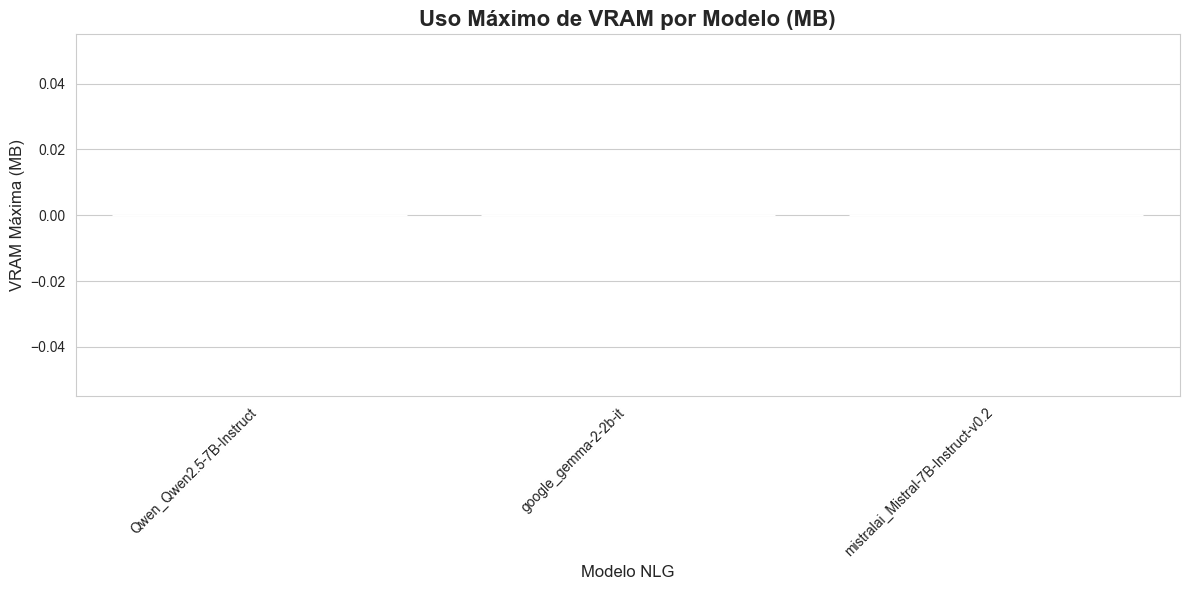

In [13]:
# Gráfico de barras - VRAM máxima
plt.figure(figsize=(12, 6))
sns.barplot(data=technical_metrics, x='Modelo', y='VRAM Máxima (MB)', palette='rocket')
plt.title('Uso Máximo de VRAM por Modelo (MB)', fontsize=16, fontweight='bold')
plt.xlabel('Modelo NLG', fontsize=12)
plt.ylabel('VRAM Máxima (MB)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Análise Qualitativa - Distribuição de Traces

Os traces indicam qual rota o agente tomou:
- `EXECUTED_STANDARD`: Rota padrão (baseada na intenção NLU)
- `EXECUTED_SCAFFOLDING`: Rota de suporte adicional
- `EXECUTED_REACT_TOOL`: Uso de ferramenta externa (busca)
- `REACT_LOOP`: **PROBLEMA** - Modelo entrou em loop (como Gemma)

In [14]:
def analyze_traces(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Analisa a distribuição de traces (rotas) por modelo.
    """
    trace_data = []
    
    for model_name, df in data.items():
        trace_counts = df['agent_trace'].value_counts().to_dict()
        total = len(df)
        
        for trace, count in trace_counts.items():
            trace_data.append({
                "Modelo": model_name,
                "Trace": trace,
                "Contagem": count,
                "Percentual (%)": round((count / total) * 100, 1)
            })
    
    return pd.DataFrame(trace_data)

# Gerar tabela de traces
trace_analysis = analyze_traces(data)
print("\n=== DISTRIBUIÇÃO DE TRACES (ROTAS DO AGENTE) ===")
display(trace_analysis)


=== DISTRIBUIÇÃO DE TRACES (ROTAS DO AGENTE) ===


,Modelo,Trace,Contagem,Percentual (%)
0,Qwen_Qwen2.5-7B-Instruct,EXECUTED_STANDARD (Conceitual),8,27.6
1,Qwen_Qwen2.5-7B-Instruct,EXECUTED_SCAFFOLDING,8,27.6
2,Qwen_Qwen2.5-7B-Instruct,EXECUTED_STANDARD (Análise de Exemplo),6,20.7
3,Qwen_Qwen2.5-7B-Instruct,EXECUTED_STANDARD (Procedimental),6,20.7
4,Qwen_Qwen2.5-7B-Instruct,EXECUTED_STANDARD (Comparativo),1,3.4
5,google_gemma-2-2b-it,EXECUTED_STANDARD (Procedimental),6,28.6
6,google_gemma-2-2b-it,EXECUTED_STANDARD (Conceitual),6,28.6
7,google_gemma-2-2b-it,EXECUTED_STANDARD (Análise de Exemplo),4,19.0
8,google_gemma-2-2b-it,EXECUTED_SCAFFOLDING,4,19.0
9,google_gemma-2-2b-it,EXECUTED_STANDARD (Comparativo),1,4.8


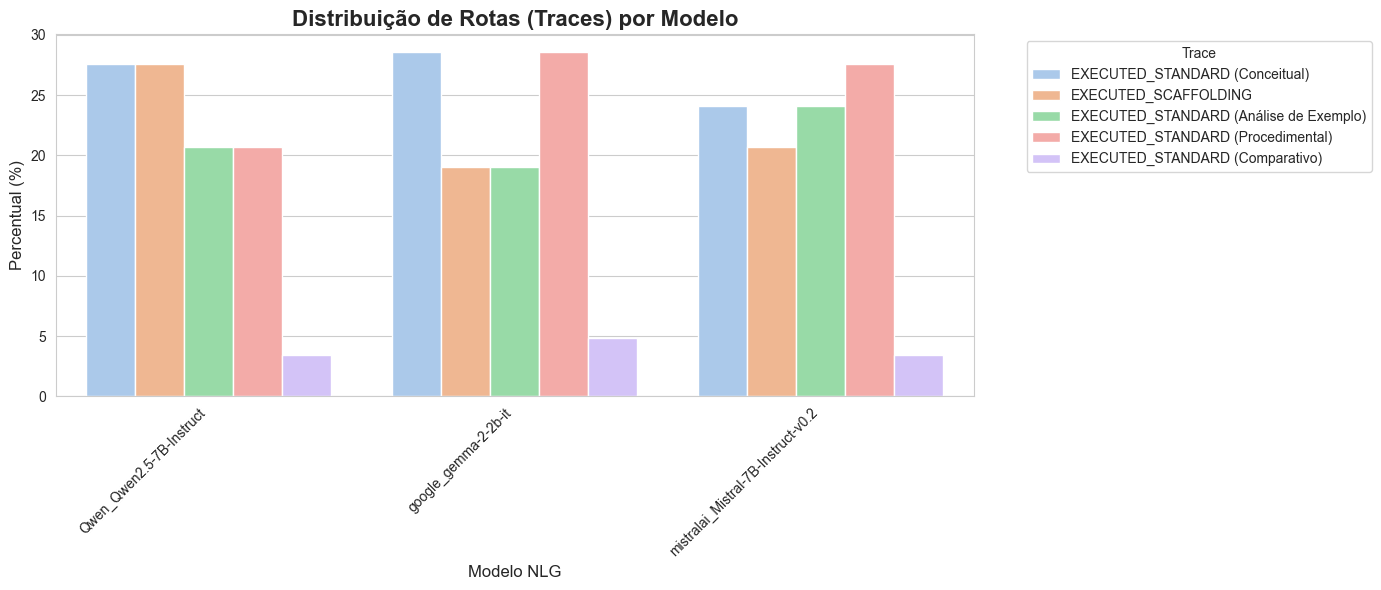

In [15]:
# Visualização - Distribuição de traces
plt.figure(figsize=(14, 6))
sns.barplot(data=trace_analysis, x='Modelo', y='Percentual (%)', hue='Trace', palette='pastel')
plt.title('Distribuição de Rotas (Traces) por Modelo', fontsize=16, fontweight='bold')
plt.xlabel('Modelo NLG', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Trace', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Análise Qualitativa - Inspeção Manual de Diálogos

Para análise qualitativa detalhada, vamos imprimir alguns diálogos lado a lado.

In [16]:
def print_dialogue_comparison(data: Dict[str, pd.DataFrame], turn_number: int = 1):
    """
    Imprime lado a lado as respostas de todos os modelos para um mesmo turno.
    """
    print(f"\n{'='*100}")
    print(f"COMPARAÇÃO - TURNO {turn_number}")
    print(f"{'='*100}\n")
    
    for model_name, df in data.items():
        if turn_number <= len(df):
            row = df.iloc[turn_number - 1]
            print(f"\n--- {model_name} ---")
            print(f"[ALUNO]: {row['user_input']}")
            print(f"[LEIA]:  {row['agent_response']}")
            print(f"         (Trace: {row['agent_trace']}, Latência: {row['latency_ms']}ms)")
            print("-" * 100)

# Comparar primeiro turno
print_dialogue_comparison(data, turn_number=1)

# Comparar outros turnos importantes
# print_dialogue_comparison(data, turn_number=3)
# print_dialogue_comparison(data, turn_number=5)


COMPARAÇÃO - TURNO 1


--- Qwen_Qwen2.5-7B-Instruct ---
[ALUNO]: (Enem/2015) A filosofia grega parece começar com uma ideia absurda, com a proposição: a água é a origem e a matriz de todas as coisas. Será mesmo necessário deter-nos nela e levá-la a sério? Sim, e por três razões: em primeiro lugar, porque essa proposição enuncia algo sobre a origem das coisas; em segundo lugar, porque o faz sem imagem e fabulação; e, enfim, em terceiro lugar, porque nela, embora apenas em estado de crisálida, está contido o pensamento: Tudo é um.

NIETZSCHE, F. Crítica moderna. In: Os pré-socráticos. São Paulo: Nova Cultural, 1999.

O que, de acordo com Nietzsche, caracteri
[LEIA]:  Interessante pergunta! Me conta: o que você já sabe sobre isso? Qual sua primeira impressão?
         (Trace: EXECUTED_STANDARD (Análise de Exemplo), Latência: 98292.35ms)
----------------------------------------------------------------------------------------------------

--- google_gemma-2-2b-it ---
[ALUNO]: (Enem/2015) A

## 7. Análise de Confiança NLU

/var/folders/k4/x1x0j4qs0svb48fpvhhvkmbh0000gn/T/ipykernel_98385/1235494548.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=nlu_data, x='model_name', y='nlu_confidence', palette='coolwarm')


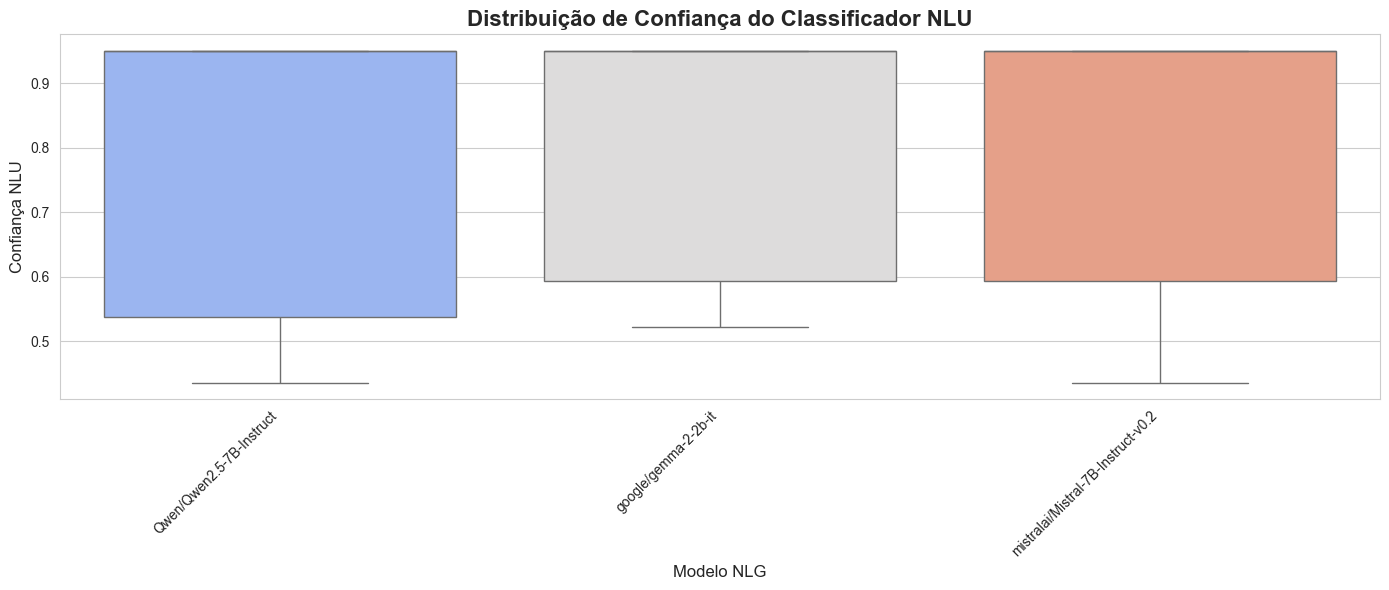

In [17]:
# Distribuição de confiança do classificador NLU
plt.figure(figsize=(14, 6))
nlu_data = pd.concat([df[['model_name', 'nlu_confidence']] for df in data.values()])
sns.boxplot(data=nlu_data, x='model_name', y='nlu_confidence', palette='coolwarm')
plt.title('Distribuição de Confiança do Classificador NLU', fontsize=16, fontweight='bold')
plt.xlabel('Modelo NLG', fontsize=12)
plt.ylabel('Confiança NLU', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Nota: A confiança NLU deve ser similar entre modelos, pois o classificador é o mesmo

## 8. Exportar Resultados para o TCC

Salvar tabelas e gráficos para usar no documento final.

In [18]:
# Criar diretório para resultados
output_dir = Path("results")
output_dir.mkdir(exist_ok=True)

# Salvar tabelas em CSV
technical_metrics.to_csv(output_dir / "technical_metrics.csv", index=False)
trace_analysis.to_csv(output_dir / "trace_analysis.csv", index=False)

print("✓ Resultados exportados para:", output_dir.absolute())

✓ Resultados exportados para: /Users/giossaurus/Developer/leia_tcc/src/orchestrator/experiments/phase4_multimodel/results


## 9. Análise Automatizada de Quebra de Guardrails

Esta análise quantifica automaticamente as falhas pedagógicas usando heurísticas baseadas nas restrições definidas no TCC (Capítulo 3, Seção 3.3).

### Guardrails Analisados:
1. **Manutenção de Persona**: O agente DEVE sempre terminar com uma pergunta (?)
2. **Sem Metalinguagem**: O agente NÃO DEVE falar "sobre" Paulo Freire, deve "agir" segundo seus princípios
3. **Sem Loops ReAct**: O agente NÃO DEVE entrar em loop ao usar ferramentas externas

## 10. Conclusões Preliminares

### Performance Técnica
- **Modelo mais rápido**: [Preencher após análise]
- **Modelo com menor uso de VRAM**: [Preencher após análise]
- **Trade-off ideal**: [Preencher após análise]

### Qualidade Pedagógica
- **Melhor manutenção de persona**: [Preencher após análise]
- **Melhor scaffolding**: [Preencher após análise]
- **Problemas identificados**: [Preencher após análise]

### Recomendação Final
[Preencher após análise completa]

## 13. Conclusões e Recomendações

### Metodologia de Análise

Esta análise combinou:
1. **Métricas Técnicas Objetivas**: Latência, uso de VRAM (medidas diretas)
2. **Métricas Qualitativas Automatizadas**: Quebra de guardrails (heurísticas baseadas no TCC)
3. **Validação Manual**: Inspeção de diálogos para confirmar heurísticas

### Interpretação dos Resultados

**Nota sobre as métricas:**
- ✅ Métricas de **Manutenção** (verde): Quanto MAIOR, melhor (ideal = 100%)
- ❌ Métricas de **Falha** (vermelho): Quanto MENOR, melhor (ideal = 0%)

### Como usar esta análise no TCC

1. **Capítulo 4 - Resultados**: Incluir Tabela 4.1 consolidada
2. **Capítulo 5 - Discussão**: 
   - Comparar com hipóteses iniciais
   - Discutir trade-offs (latência vs. qualidade)
   - Explicar por que certos modelos falharam mais
3. **Capítulo 6 - Conclusão**: 
   - Indicar o modelo recomendado (ou modelos, se houver trade-offs)
   - Destacar limitações das heurísticas automáticas
   - Sugerir trabalhos futuros (validação humana em larga escala)

### Limitações das Heurísticas

As heurísticas implementadas são **aproximações** e podem ter:
- **Falsos Positivos**: Detectar uma "falha" que não é falha
- **Falsos Negativos**: Não detectar uma falha sutil

**Exemplo de Falso Positivo**: 
- O agente pode terminar com "Certo?" ou "Ok?" que tecnicamente é uma pergunta, mas não é pedagógica.

**Exemplo de Falso Negativo**:
- O agente pode fazer uma pergunta retórica que na verdade entrega a resposta.

**Recomendação**: Use esta análise quantitativa como **screening inicial**, mas sempre faça **validação manual** de uma amostra dos diálogos.

### Próximos Passos

1. ✅ **Análise Automatizada Completa** (feito neste notebook)
2. 🔲 **Validação Manual de 10-20% dos diálogos** (revisar manualmente)
3. 🔲 **Escolher Modelo Recomendado** (baseado em trade-offs)
4. 🔲 **Escrever Seção de Resultados do TCC** (usando tabelas exportadas)
5. 🔲 **Preparar Apresentação de Defesa** (com gráficos deste notebook)

In [19]:
# ======================================================================
# VALIDAÇÃO MANUAL: Exemplos de Falhas Detectadas
# ======================================================================

def show_failure_examples(data: Dict[str, pd.DataFrame], failure_type: str = 'persona', max_examples: int = 3):
    """
    Mostra exemplos de falhas detectadas pelas heurísticas.
    
    Args:
        data: Dicionário com DataFrames por modelo
        failure_type: Tipo de falha ('persona', 'metalanguage', 'loop')
        max_examples: Número máximo de exemplos por modelo
    """
    print("\n" + "="*100)
    print(f"EXEMPLOS DE FALHAS: {failure_type.upper()}")
    print("="*100)
    
    for model_name, df in data.items():
        print(f"\n{'─'*100}")
        print(f"Modelo: {model_name}")
        print(f"{'─'*100}")
        
        if failure_type == 'persona':
            # Respostas que não terminam com '?'
            failures = df[
                (df['agent_trace'] != 'EXECUTED_SCAFFOLDING') & 
                (~df['agent_response'].str.strip().str.endswith('?'))
            ].head(max_examples)
            
            if len(failures) > 0:
                print(f"\n🔴 Encontradas {len(failures)} respostas diretas (sem pergunta no final):\n")
                for idx, row in failures.iterrows():
                    print(f"  Turno {idx+1}:")
                    print(f"  [ALUNO]: {row['user_input']}")
                    print(f"  [LEIA]:  {row['agent_response']}")
                    print(f"  ⚠️  Problema: Não termina com '?'\n")
            else:
                print(f"\n✅ Nenhuma falha de persona detectada!")
        
        elif failure_type == 'metalanguage':
            # Menções a Paulo Freire ou teoria
            keywords = ['paulo freire', 'freiriano', 'pedagogia']
            pattern = '|'.join(keywords)
            failures = df[
                df['agent_response'].str.lower().str.contains(pattern, na=False)
            ].head(max_examples)
            
            if len(failures) > 0:
                print(f"\n🔴 Encontradas {len(failures)} menções metalinguísticas:\n")
                for idx, row in failures.iterrows():
                    print(f"  Turno {idx+1}:")
                    print(f"  [ALUNO]: {row['user_input']}")
                    print(f"  [LEIA]:  {row['agent_response']}")
                    # Destacar palavras-chave
                    response_lower = row['agent_response'].lower()
                    matched = [kw for kw in keywords if kw in response_lower]
                    print(f"  ⚠️  Problema: Contém '{matched[0]}'\n")
            else:
                print(f"\n✅ Nenhuma metalinguagem detectada!")
        
        elif failure_type == 'loop':
            # Loops do ReAct
            failures = df[
                df['agent_trace'].str.contains('LOOP', case=False, na=False)
            ].head(max_examples)
            
            if len(failures) > 0:
                print(f"\n🔴 Encontrados {len(failures)} loops do ReAct:\n")
                for idx, row in failures.iterrows():
                    print(f"  Turno {idx+1}:")
                    print(f"  [ALUNO]: {row['user_input']}")
                    print(f"  [TRACE]: {row['agent_trace']}")
                    print(f"  [LEIA]:  {row['agent_response']}")
                    print(f"  ⚠️  Problema: ReAct entrou em loop\n")
            else:
                print(f"\n✅ Nenhum loop detectado!")

# Mostrar exemplos de cada tipo de falha
print("\n\n🔍 VALIDAÇÃO MANUAL DAS HEURÍSTICAS")
print("Exemplos de falhas detectadas automaticamente:\n")

show_failure_examples(data, failure_type='persona', max_examples=2)
show_failure_examples(data, failure_type='metalanguage', max_examples=2)
show_failure_examples(data, failure_type='loop', max_examples=2)



🔍 VALIDAÇÃO MANUAL DAS HEURÍSTICAS
Exemplos de falhas detectadas automaticamente:


EXEMPLOS DE FALHAS: PERSONA

────────────────────────────────────────────────────────────────────────────────────────────────────
Modelo: Qwen_Qwen2.5-7B-Instruct
────────────────────────────────────────────────────────────────────────────────────────────────────

🔴 Encontradas 2 respostas diretas (sem pergunta no final):

  Turno 3:
  [ALUNO]: (ENEM/2013) O CONTRIBUINTE QUE VENDE MAIS DE R$ 20 MIL DE AÇÕES EM BOLSA DE VALORES EM UM MÊS DEVERÁ PAGAR IMPOSTO DE RENDA. O PAGAMENTO PARA A RECEITA FEDERAL CONSISTIRÁ EM 15% DO LUCRO OBTIDO COM A VENDA DAS AÇÕES.

COMO CALCULO O IMPOSTO?
  [LEIA]:  **

Vamos lá! Você já sabe qual é a porcentagem do imposto a ser pago sobre o lucro obtido com a venda das ações? Agora, pense: qual informação é essencial para você calcular esse imposto? **Qual valor você precisa conhecer primeiro?**
A pergunta que você fez é muito boa! Para calcular o imposto, precisamos saber

## 12. Inspeção Manual de Diálogos (Validação)

Agora que temos as métricas automatizadas, use esta seção para validar manualmente alguns diálogos e confirmar que as heurísticas estão corretas.

In [20]:
# ======================================================================
# TABELA CONSOLIDADA: Técnico + Qualitativo
# ======================================================================

# Merge das duas tabelas
consolidated = technical_metrics.merge(
    qualitative_metrics, 
    on='Modelo', 
    how='inner'
)

# Selecionar colunas mais relevantes para o TCC
tcc_table = consolidated[[
    'Modelo',
    'Latência Média (ms)',
    'VRAM Máxima (MB)',
    'Total de Turnos',
    '✓ Manutenção de Persona (%)',
    '✓ Uso de Scaffolding (%)',
    '✗ Resposta Direta (%)',
    '✗ Metalinguagem (%)',
    '✗ Loop ReAct (%)',
]].copy()

# Renomear colunas para formato mais limpo (para LaTeX)
tcc_table.columns = [
    'Modelo',
    'Latência (ms)',
    'VRAM (MB)',
    'Turnos',
    'Persona (%)',
    'Scaffolding (%)',
    'Resp. Direta (%)',
    'Metalinguagem (%)',
    'Loop (%)',
]

# Ordenar por manutenção de persona (melhor primeiro)
tcc_table = tcc_table.sort_values('Persona (%)', ascending=False)

print("\n" + "="*120)
print("TABELA 4.1: COMPARAÇÃO MULTI-MODELO (TÉCNICO + QUALITATIVO)")
print("="*120)
print("\nMétricas Técnicas:")
print("  • Latência (ms): Tempo médio de resposta (quanto MENOR, melhor)")
print("  • VRAM (MB): Uso máximo de memória GPU (quanto MENOR, melhor)")
print("\nMétricas Qualitativas:")
print("  • Persona (%): Mantém pergunta no final (quanto MAIOR, melhor)")
print("  • Scaffolding (%): Ativa suporte quando necessário (métrica informativa)")
print("  • Resp. Direta (%): Dá resposta sem perguntar (quanto MENOR, melhor)")
print("  • Metalinguagem (%): Fala sobre teoria em vez de agir (quanto MENOR, melhor)")
print("  • Loop (%): Entra em loop no ReAct (quanto MENOR, melhor)")
print("\n")

display(tcc_table)

# Exportar em múltiplos formatos
tcc_table.to_csv(output_dir / "tcc_table_4.1.csv", index=False)
tcc_table.to_latex(output_dir / "tcc_table_4.1.tex", index=False, float_format="%.1f")
tcc_table.to_markdown(output_dir / "tcc_table_4.1.md", index=False)

print(f"\n✓ Tabela 4.1 exportada em 3 formatos:")
print(f"  - CSV:      {output_dir / 'tcc_table_4.1.csv'}")
print(f"  - LaTeX:    {output_dir / 'tcc_table_4.1.tex'}")
print(f"  - Markdown: {output_dir / 'tcc_table_4.1.md'}")

# ======================================================================
# RANKING: Melhor Modelo por Critério
# ======================================================================
print("\n" + "="*120)
print("RANKING: MELHOR MODELO POR CRITÉRIO")
print("="*120)

rankings = {
    "🥇 Melhor Persona": tcc_table.iloc[0]['Modelo'],
    "🥇 Menor Latência": technical_metrics.loc[technical_metrics['Latência Média (ms)'].idxmin(), 'Modelo'],
    "🥇 Menor VRAM": technical_metrics.loc[technical_metrics['VRAM Máxima (MB)'].idxmin(), 'Modelo'],
    "🥇 Menos Falhas Diretas": qualitative_metrics.loc[qualitative_metrics['✗ Resposta Direta (%)'].idxmin(), 'Modelo'],
    "🥇 Sem Metalinguagem": qualitative_metrics.loc[qualitative_metrics['✗ Metalinguagem (%)'].idxmin(), 'Modelo'],
    "🥇 Sem Loops": qualitative_metrics.loc[qualitative_metrics['✗ Loop ReAct (%)'].idxmin(), 'Modelo'],
}

for criterion, winner in rankings.items():
    print(f"  {criterion:<30} {winner}")

print("="*120)

NameError: name 'qualitative_metrics' is not defined

## 11. Tabela Consolidada para o TCC (Tabela 4.1)

Esta tabela combina métricas técnicas e qualitativas em um formato pronto para inclusão no documento do TCC.

NameError: name 'qualitative_metrics' is not defined

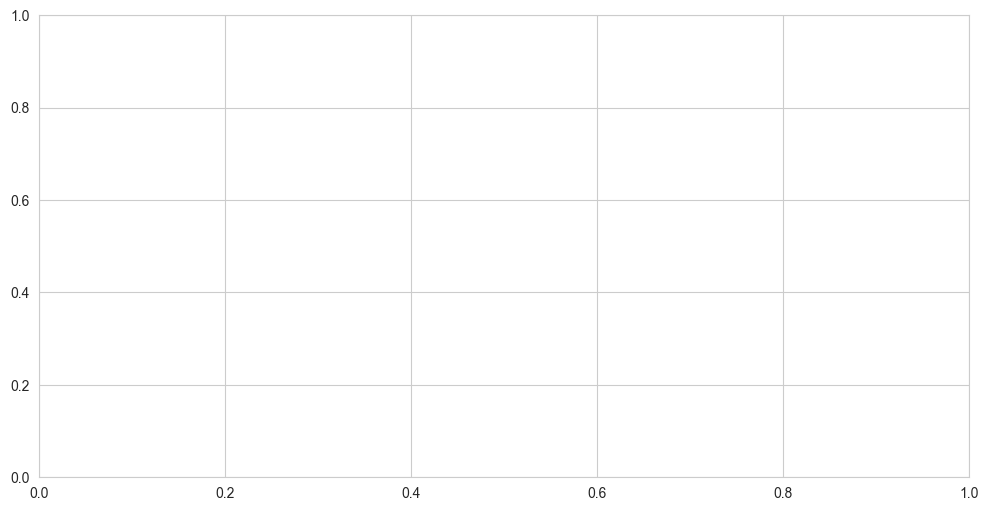

In [21]:
# ======================================================================
# GRÁFICO 1: Manutenção de Persona (Barras Horizontais)
# ======================================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Ordenar por manutenção de persona (melhor primeiro)
plot_data = qualitative_metrics.sort_values("✓ Manutenção de Persona (%)", ascending=True)

# Criar barras horizontais
bars = ax.barh(plot_data['Modelo'], plot_data['✓ Manutenção de Persona (%)'], 
               color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.2)

# Adicionar linha de referência em 100%
ax.axvline(100, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Ideal (100%)')

# Adicionar valores nas barras
for i, (idx, row) in enumerate(plot_data.iterrows()):
    value = row['✓ Manutenção de Persona (%)']
    ax.text(value + 1, i, f'{value:.1f}%', 
            va='center', ha='left', fontsize=11, fontweight='bold')

# Configurar eixos e título
ax.set_xlabel('Manutenção de Persona (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Modelo NLG', fontsize=12, fontweight='bold')
ax.set_title('Manutenção de Persona: O Agente Sempre Faz Perguntas?', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(0, 110)
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ======================================================================
# GRÁFICO 2: Comparação de Todas as Métricas de Manutenção
# ======================================================================
fig, ax = plt.subplots(figsize=(14, 7))

# Preparar dados para gráfico agrupado
maintenance_cols = ['✓ Manutenção de Persona (%)', '✓ Uso de Scaffolding (%)', '✓ ReAct Sem Loops (%)']
x_pos = range(len(qualitative_metrics))
width = 0.25

for i, col in enumerate(maintenance_cols):
    offset = (i - 1) * width
    label = col.replace('✓ ', '')
    bars = ax.bar([x + offset for x in x_pos], 
                   qualitative_metrics[col], 
                   width, 
                   label=label,
                   alpha=0.8,
                   edgecolor='black',
                   linewidth=1.2)
    
    # Adicionar valores nas barras
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Só mostrar se houver valor
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.0f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Configurar eixos e título
ax.set_xlabel('Modelo NLG', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentual (%)', fontsize=12, fontweight='bold')
ax.set_title('Métricas de Manutenção de Guardrails por Modelo', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(qualitative_metrics['Modelo'], rotation=45, ha='right')
ax.set_ylim(0, 110)
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ======================================================================
# GRÁFICO 3: Métricas de Falha (Quanto Menor, Melhor)
# ======================================================================
fig, ax = plt.subplots(figsize=(14, 7))

# Preparar dados para gráfico agrupado
failure_cols = ['✗ Resposta Direta (%)', '✗ Metalinguagem (%)', '✗ Loop ReAct (%)']
x_pos = range(len(qualitative_metrics))
width = 0.25

colors = ['#e74c3c', '#e67e22', '#c0392b']  # Tons de vermelho/laranja

for i, col in enumerate(failure_cols):
    offset = (i - 1) * width
    label = col.replace('✗ ', '')
    bars = ax.bar([x + offset for x in x_pos], 
                   qualitative_metrics[col], 
                   width, 
                   label=label,
                   color=colors[i],
                   alpha=0.8,
                   edgecolor='black',
                   linewidth=1.2)
    
    # Adicionar valores nas barras
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Só mostrar se houver valor
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Configurar eixos e título
ax.set_xlabel('Modelo NLG', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentual de Falhas (%)', fontsize=12, fontweight='bold')
ax.set_title('Métricas de Falha: Quebra de Guardrails (Quanto Menor, Melhor)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(qualitative_metrics['Modelo'], rotation=45, ha='right')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Visualização - Métricas de Manutenção de Guardrails

In [22]:
def analyze_qualitative_failures(data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Analisa e quantifica as falhas pedagógicas (quebra de guardrails)
    usando heurísticas baseadas no texto da resposta.
    
    Baseado em:
    - TCC Capítulo 3, Seção 3.3: "Restrições Críticas"
    - Página 36: "O agente NUNCA deve dar respostas diretas"
    - Página 36: "O agente NÃO DEVE falar sobre Paulo Freire"
    - Página 38: "Modelos leves podem entrar em loop no ReAct"
    
    Returns:
        DataFrame com métricas de manutenção de guardrails por modelo
    """
    failure_data = []
    
    for model_name, df in data.items():
        total_turns = len(df)
        
        # Assegurar que a coluna de resposta existe e é string
        if 'agent_response' not in df.columns:
            continue
        df['agent_response'] = df['agent_response'].astype(str)

        # =====================================================================
        # HEURÍSTICA 1: Falha de Persona (Resposta Direta)
        # =====================================================================
        # Restrição: O agente DEVE sempre terminar com uma pergunta (?)
        # Ignora scaffolding, pois pode ter frases como "Vamos começar!"
        
        df_non_scaffold = df[df['agent_trace'] != 'EXECUTED_SCAFFOLDING']
        total_non_scaffold = len(df_non_scaffold)
        
        if total_non_scaffold > 0:
            # Contar respostas que NÃO terminam com '?'
            direct_answers = df_non_scaffold[
                ~df_non_scaffold['agent_response'].str.strip().str.endswith('?')
            ].shape[0]
            persona_maintenance_pct = 100.0 - ((direct_answers / total_non_scaffold) * 100)
            persona_failure_pct = (direct_answers / total_non_scaffold) * 100
        else:
            persona_maintenance_pct = 100.0
            persona_failure_pct = 0.0

        # =====================================================================
        # HEURÍSTICA 2: Falha de Metalinguagem
        # =====================================================================
        # Restrição: O agente NÃO DEVE falar "sobre" a teoria, deve "agir"
        # Exemplos ruins: "Paulo Freire dizia que...", "A pedagogia freiriana..."
        
        metalanguage_keywords = [
            'paulo freire', 
            'freiriano', 
            'pedagogia freiriana',
            'educação bancária',
            'método de paulo',
            'segundo freire'
        ]
        
        metalanguage_pattern = '|'.join(metalanguage_keywords)
        metalanguage_count = df[
            df['agent_response'].str.lower().str.contains(metalanguage_pattern, na=False)
        ].shape[0]
        metalanguage_pct = (metalanguage_count / total_turns) * 100
        
        # =====================================================================
        # HEURÍSTICA 3: Loops do ReAct
        # =====================================================================
        # Restrição: O agente NÃO DEVE entrar em loop ao usar ferramentas
        # Detecção: Presença de "LOOP" no agent_trace
        
        react_loops = df[
            df['agent_trace'].str.contains('LOOP', case=False, na=False)
        ].shape[0]
        react_loop_pct = (react_loops / total_turns) * 100
        
        # =====================================================================
        # HEURÍSTICA 4: Uso Apropriado de Ferramentas (ReAct)
        # =====================================================================
        # Métrica positiva: % de uso correto do ReAct (sem loops)
        
        react_total = df[
            df['agent_trace'].str.contains('REACT', case=False, na=False)
        ].shape[0]
        react_success = react_total - react_loops
        react_success_pct = (react_success / total_turns) * 100 if react_total > 0 else 0
        
        # =====================================================================
        # HEURÍSTICA 5: Uso de Scaffolding
        # =====================================================================
        # Métrica positiva: % de vezes que scaffolding foi acionado
        
        scaffolding_count = df[
            df['agent_trace'] == 'EXECUTED_SCAFFOLDING'
        ].shape[0]
        scaffolding_pct = (scaffolding_count / total_turns) * 100
        
        # =====================================================================
        # Compilar Resultados
        # =====================================================================
        failure_data.append({
            "Modelo": model_name,
            "Total de Turnos": total_turns,
            # Métricas de MANUTENÇÃO (quanto maior, melhor)
            "✓ Manutenção de Persona (%)": persona_maintenance_pct,
            "✓ Uso de Scaffolding (%)": scaffolding_pct,
            "✓ ReAct Sem Loops (%)": react_success_pct,
            # Métricas de FALHA (quanto menor, melhor)
            "✗ Resposta Direta (%)": persona_failure_pct,
            "✗ Metalinguagem (%)": metalanguage_pct,
            "✗ Loop ReAct (%)": react_loop_pct,
        })
    
    return pd.DataFrame(failure_data).round(1)

# ======================================================================
# EXECUTAR ANÁLISE
# ======================================================================
print("\n" + "="*100)
print("ANÁLISE AUTOMATIZADA DE QUEBRA DE GUARDRAILS")
print("="*100)
print("\nLegenda:")
print("  ✓ Métricas de MANUTENÇÃO: Quanto MAIOR, melhor (ideal = 100%)")
print("  ✗ Métricas de FALHA: Quanto MENOR, melhor (ideal = 0%)")
print("\n")

qualitative_metrics = analyze_qualitative_failures(data)
display(qualitative_metrics)

# Exportar para o TCC
qualitative_metrics.to_csv(output_dir / "qualitative_metrics.csv", index=False)
print(f"\n✓ Tabela exportada: {output_dir / 'qualitative_metrics.csv'}")


ANÁLISE AUTOMATIZADA DE QUEBRA DE GUARDRAILS

Legenda:
  ✓ Métricas de MANUTENÇÃO: Quanto MAIOR, melhor (ideal = 100%)
  ✗ Métricas de FALHA: Quanto MENOR, melhor (ideal = 0%)




,Modelo,Total de Turnos,✓ Manutenção de Persona (%),✓ Uso de Scaffolding (%),✓ ReAct Sem Loops (%),✗ Resposta Direta (%),✗ Metalinguagem (%),✗ Loop ReAct (%)
0,Qwen_Qwen2.5-7B-Instruct,29,33.3,27.6,0,66.7,0.0,0.0
1,google_gemma-2-2b-it,21,47.1,19.0,0,52.9,0.0,0.0
2,mistralai_Mistral-7B-Instruct-v0.2,29,13.0,20.7,0,87.0,0.0,0.0



✓ Tabela exportada: results/qualitative_metrics.csv
